# Which factors are linked to stroke? A small statistics project in Python

**Main question:** In this dataset, which factors (age, high blood pressure, heart disease, blood glucose, BMI, smoking) are linked to having a stroke?

**My own extra question:** Do men and women show a different stroke pattern?

**Why this topic:** A stroke happens when blood supply to a part of the brain is cut off. I am a biology graduate learning Python and statistics, and I want to move towards health data and precision medicine.

**Data:** Stroke Prediction Dataset (public, from Kaggle). Each row is one person.

**Tools:** Python, pandas, matplotlib, seaborn, scipy, statsmodels.

**Important:** This is a learning project. It shows associations in one dataset. It is not medical advice and does not prove that one thing causes another.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

sns.set_theme()
print("Libraries loaded")

Libraries loaded


## 2. Load and look at the data
I load the CSV file and check its size, the first rows, missing values and how many people had a stroke.

In [2]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
print("Rows and columns:", df.shape)
df.head()

Rows and columns: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
df.info()
print()
print("Missing values per column:")
print(df.isna().sum())
print()
print("Stroke counts (0 = no, 1 = yes):")
print(df["stroke"].value_counts())
print()
print(df["gender"].value_counts())
print()
print(df["smoking_status"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB

Missing values per column:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever

**What I notice:** The data has 5110 people and 12 columns. Only 249 people (about 5%) had a stroke, so stroke cases are few compared with non-stroke cases. The column `bmi` has 201 missing values. The column `gender` has one person marked "Other". About 30% of people have smoking status "Unknown".

## 3. Clean the data
I remove the id column (not useful), the one "Other" gender row (too few to analyse), and rows where BMI is missing. I keep a record of how many rows I lose.

In [4]:
rows_before = len(df)

df = df.drop(columns=["id"])
df = df[df["gender"] != "Other"]
df["bmi"] = pd.to_numeric(df["bmi"], errors="coerce")
df = df.dropna(subset=["bmi"])

df["stroke_label"] = df["stroke"].map({0: "No stroke", 1: "Stroke"})

print("Rows before:", rows_before)
print("Rows after:", len(df))
print("Rows removed:", rows_before - len(df))
print()
print(df["stroke"].value_counts())
print("Stroke rate:", round(df["stroke"].mean() * 100, 2), "%")

Rows before: 5110
Rows after: 4908
Rows removed: 202

stroke
0    4699
1     209
Name: count, dtype: int64
Stroke rate: 4.26 %


**What I notice:** I removed 202 rows (201 with missing BMI and 1 "Other"). 4908 people remain, and 209 of them (about 4.3%) had a stroke. People with missing BMI might be different from the rest, so this is a limitation.

## 4. Basic numbers
First I compare the average age, glucose and BMI between people with and without stroke. Then I look at the stroke rate inside each group (for example people with and without hypertension).

In [5]:
summary = df.groupby("stroke_label")[["age", "avg_glucose_level", "bmi"]].agg(["mean", "median", "std"]).round(2)
summary

age               avg_glucose_level                   bmi  \
               mean median    std              mean  median    std   mean   
stroke_label                                                                
No stroke     41.76   43.0  22.27            104.00   91.21  43.00  28.82   
Stroke        67.71   70.0  12.40            134.57  106.58  62.46  30.47   

                           
             median   std  
stroke_label               
No stroke      28.0  7.91  
Stroke         29.7  6.33

In [6]:
for col in ["gender", "hypertension", "heart_disease", "ever_married", "work_type", "Residence_type", "smoking_status"]:
    table = df.groupby(col)["stroke"].agg(["count", "mean"]).round(3)
    table = table.rename(columns={"mean": "stroke_rate"})
    print(table)
    print()

        count  stroke_rate
gender                    
Female   2897        0.041
Male     2011        0.044

              count  stroke_rate
hypertension                    
0              4457        0.033
1               451        0.133

               count  stroke_rate
heart_disease                    
0               4665        0.036
1                243        0.165

              count  stroke_rate
ever_married                    
No             1704        0.013
Yes            3204        0.058

               count  stroke_rate
work_type                        
Govt_job         630        0.044
Never_worked      22        0.000
Private         2810        0.045
Self-employed    775        0.068
children         671        0.001

                count  stroke_rate
Residence_type                    
Rural            2418        0.041
Urban            2490        0.044

                 count  stroke_rate
smoking_status                     
Unknown           1483        0.020


## 5. Charts
Box plots show the middle 50% of the values (the box) and the median (the line inside the box).

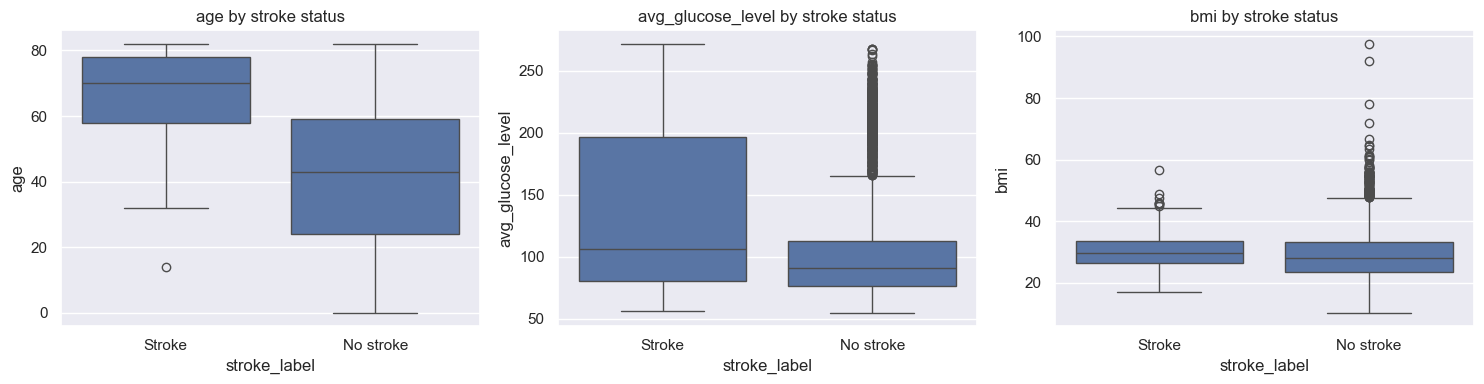

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["age", "avg_glucose_level", "bmi"]):
    sns.boxplot(data=df, x="stroke_label", y=col, ax=ax)
    ax.set_title(col + " by stroke status")
plt.tight_layout()
plt.savefig("fig1_boxplots.png", dpi=150)
plt.show()

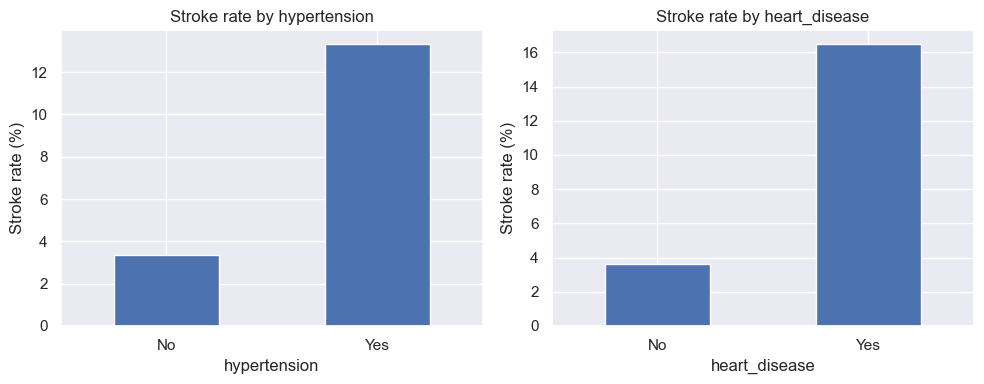

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col in zip(axes, ["hypertension", "heart_disease"]):
    rates = df.groupby(col)["stroke"].mean() * 100
    rates.plot(kind="bar", ax=ax)
    ax.set_ylabel("Stroke rate (%)")
    ax.set_title("Stroke rate by " + col)
    ax.set_xticklabels(["No", "Yes"], rotation=0)
plt.tight_layout()
plt.savefig("fig2_stroke_rates.png", dpi=150)
plt.show()

**What I notice:** People with a stroke are much older (average about 68 years, against about 42 years). Their average glucose is also higher. The stroke rate is about 13% in people with hypertension against about 3% in people without it, and about 17% in people with heart disease against about 4% in people without it. Men and women have very similar rates. Children and people who never married have very low rates, but this is probably because they are younger, not because of marriage or work itself.

The age box for the stroke group sits far higher than for the no-stroke group. Glucose is also higher in the stroke group and spread over a wider range. BMI looks almost the same in both groups. The bar charts show a clearly higher stroke rate for people with hypertension and for people with heart disease.

## 6. Statistical tests
Charts can look convincing by chance, so I use tests. For the numeric columns I use the **Mann-Whitney U test** (it does not assume a normal distribution, and glucose and BMI are skewed). For the yes/no and category columns I use the **chi-square test of independence**. A p-value below 0.05 is the usual cut-off for calling a difference unlikely to be just chance.

In [9]:
print("Mann-Whitney U test (stroke vs no stroke)")
for col in ["age", "avg_glucose_level", "bmi"]:
    with_stroke = df[df["stroke"] == 1][col]
    without_stroke = df[df["stroke"] == 0][col]
    stat, p = stats.mannwhitneyu(with_stroke, without_stroke)
    print(f"{col}: median {with_stroke.median():.1f} (stroke) vs {without_stroke.median():.1f} (no stroke), p = {p:.2g}")

Mann-Whitney U test (stroke vs no stroke)
age: median 70.0 (stroke) vs 43.0 (no stroke), p = 6.4e-61
avg_glucose_level: median 106.6 (stroke) vs 91.2 (no stroke), p = 8e-10
bmi: median 29.7 (stroke) vs 28.0 (no stroke), p = 0.0001


In [10]:
print("Chi-square test of independence with stroke")
rows = []
for col in ["gender", "hypertension", "heart_disease", "ever_married", "work_type", "Residence_type", "smoking_status"]:
    table = pd.crosstab(df[col], df["stroke"])
    chi2, p, dof, expected = stats.chi2_contingency(table)
    rows.append({"variable": col, "chi2": round(chi2, 2), "p_value": float(f"{p:.2g}")})
pd.DataFrame(rows)

Chi-square test of independence with stroke


,variable,chi2,p_value
0,gender,0.17,6.800000e-01
1,hypertension,97.24,6.100000e-23
2,heart_disease,90.25,2.100000e-21
3,ever_married,53.08,3.200000e-13
4,work_type,41.95,1.700000e-08
5,Residence_type,0.12,7.300000e-01
6,smoking_status,35.01,1.200000e-07


**What I notice:** Age, glucose and BMI are all different between the two groups (p below 0.05), but the BMI difference is small (medians 29.7 against 28.0), so I should not read too much into it. Hypertension, heart disease, marital status, work type and smoking status are linked with stroke. Gender and residence type (rural or urban) are **not** linked (p about 0.68 and 0.73).

## 7. Logistic regression
The tests above look at one factor at a time. But age is linked to almost everything (older people have more hypertension, are more often married, and so on). So I use **logistic regression**, which looks at all the factors together and shows the effect of each one while the others are kept fixed.

The result is shown as an **odds ratio (OR)**. OR above 1 means higher odds of stroke, OR below 1 means lower odds, and OR of 1 means no effect. I use age in units of 10 years and glucose in units of 10 mg/dL so the numbers are easy to read. If the 95% confidence interval includes 1, the result is not clearly different from "no effect".

In [11]:
model_df = df.copy()
model_df["age10"] = model_df["age"] / 10
model_df["glucose10"] = model_df["avg_glucose_level"] / 10
model_df["smoking"] = model_df["smoking_status"]

formula = ("stroke ~ age10 + C(gender) + hypertension + heart_disease + glucose10 + bmi "
           "+ C(smoking, Treatment('never smoked'))")
model = smf.logit(formula, data=model_df).fit(disp=0)

odds = pd.DataFrame({
    "odds_ratio": np.exp(model.params),
    "ci_low": np.exp(model.conf_int()[0]),
    "ci_high": np.exp(model.conf_int()[1]),
    "p_value": model.pvalues
}).drop(index="Intercept")

nice_names = {
    "age10": "Age (per 10 years)",
    "C(gender)[T.Male]": "Male (vs female)",
    "hypertension": "Hypertension",
    "heart_disease": "Heart disease",
    "glucose10": "Glucose (per 10 mg/dL)",
    "bmi": "BMI (per 1 unit)",
    "C(smoking, Treatment('never smoked'))[T.Unknown]": "Smoking: unknown (vs never)",
    "C(smoking, Treatment('never smoked'))[T.formerly smoked]": "Smoking: formerly (vs never)",
    "C(smoking, Treatment('never smoked'))[T.smokes]": "Smoking: current (vs never)",
}
odds.index = [nice_names.get(i, i) for i in odds.index]
odds.round(3)

,odds_ratio,ci_low,ci_high,p_value
Male (vs female),0.989,0.731,1.337,0.942
Smoking: unknown (vs never),0.819,0.522,1.287,0.388
Smoking: formerly (vs never),1.059,0.733,1.531,0.759
Smoking: current (vs never),1.461,0.962,2.218,0.075
Age (per 10 years),1.995,1.779,2.237,0.000
Hypertension,1.678,1.192,2.362,0.003
Heart disease,1.452,0.969,2.174,0.070
Glucose (per 10 mg/dL),1.048,1.022,1.075,0.000
BMI (per 1 unit),1.003,0.981,1.027,0.768


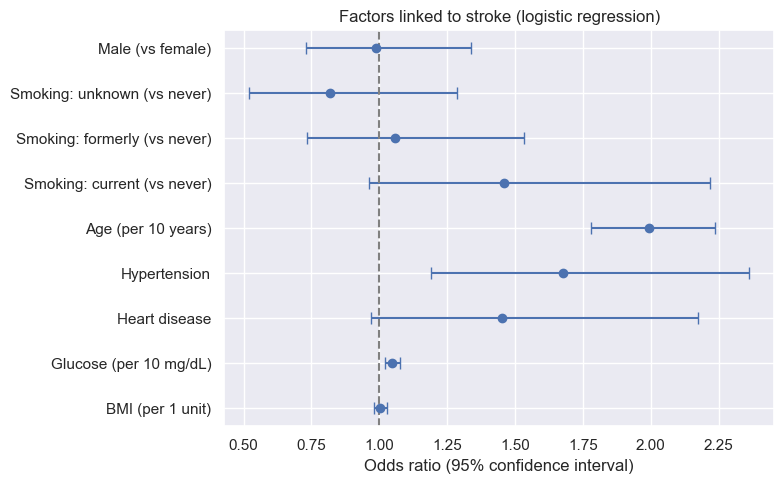

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_df = odds.iloc[::-1]
ypos = np.arange(len(plot_df))
ax.errorbar(plot_df["odds_ratio"], ypos,
            xerr=[plot_df["odds_ratio"] - plot_df["ci_low"], plot_df["ci_high"] - plot_df["odds_ratio"]],
            fmt="o", capsize=4)
ax.axvline(1, linestyle="--", color="gray")
ax.set_yticks(ypos)
ax.set_yticklabels(plot_df.index)
ax.set_xlabel("Odds ratio (95% confidence interval)")
ax.set_title("Factors linked to stroke (logistic regression)")
plt.tight_layout()
plt.savefig("fig3_odds_ratios.png", dpi=150)
plt.show()

**What I notice:** Age is the strongest factor: every 10 extra years roughly doubles the odds of stroke (OR about 2.0). Hypertension is linked with higher odds (OR about 1.7) and higher glucose is also linked (about 5% higher odds for every 10 mg/dL). Heart disease (OR about 1.45) and current smoking (OR about 1.46) point in the same direction, but their confidence intervals touch 1, so I cannot say they are clearly linked once age and the other factors are taken into account. BMI and gender show no clear effect.

## 8. My own question: do men and women show a different pattern?
I compare the stroke rate of men and women inside three age groups, because age is the biggest factor and I do not want it to hide a real difference.

                     count  stroke_rate
age_group    gender                    
Under 40     Female   1244        0.005
             Male      869        0.000
40 to 59     Female    901        0.033
             Male      609        0.038
60 and above Female    752        0.112
             Male      533        0.124


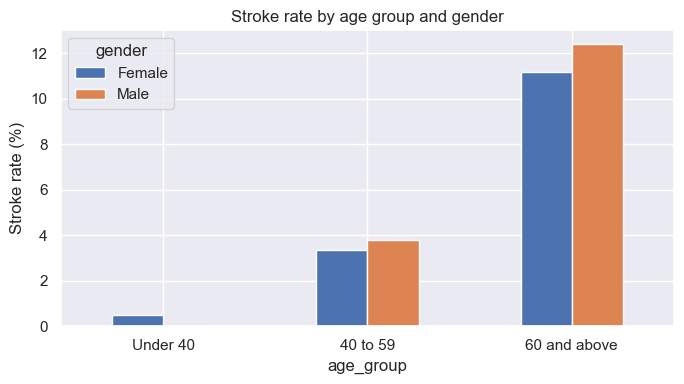

In [13]:
df["age_group"] = pd.cut(df["age"], bins=[0, 40, 60, 100], labels=["Under 40", "40 to 59", "60 and above"], right=False)

by_group = df.groupby(["age_group", "gender"], observed=True)["stroke"].agg(["count", "mean"]).round(3)
by_group = by_group.rename(columns={"mean": "stroke_rate"})
print(by_group)

rates = df.groupby(["age_group", "gender"], observed=True)["stroke"].mean().unstack() * 100
rates.plot(kind="bar", figsize=(7, 4))
plt.ylabel("Stroke rate (%)")
plt.title("Stroke rate by age group and gender")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("fig4_gender_age.png", dpi=150)
plt.show()

**What I notice:** In every age group the stroke rate of men and women is very close, and the overall test (section 6) and the regression (section 7) also show no clear gender difference. So in this dataset I do not find a different stroke pattern between men and women. Very few people under 40 had a stroke, so that group says little.

## 9. Conclusion
- Age is by far the strongest factor linked with stroke in this dataset.
- Hypertension and higher blood glucose are also linked with stroke, even after taking age and the other factors into account.
- Heart disease and current smoking show a similar direction, but the evidence is not clear in this data.
- BMI, gender and rural or urban residence show no clear link.
- Men and women show a similar pattern.

## 10. Limitations (what this project cannot tell)
- **Association is not cause.** The data is one snapshot in time. It cannot show that hypertension causes stroke, only that the two go together here.
- **Few stroke cases.** Only 209 people with stroke remain after cleaning, so the estimates have wide confidence intervals.
- **Removed rows.** I removed 202 rows (mostly missing BMI). If those people differ from the rest, the results could be shifted.
- **Unknown smoking status.** About 30% of people have "Unknown", which makes the smoking result weaker.
- **Unclear source.** The original source and collection method of this dataset are not clearly documented, so I treat the results as practice and not as medical evidence.
- **Simple model.** The regression assumes each factor changes the odds in a straight, additive way. I did not build a prediction model or test how well it would work on new people.

## 11. What I want to learn next
- Learn statistics properly (confidence intervals, model checking) through a structured course.
- Learn R and SQL, and repeat this kind of analysis on genomic or clinical data.
- Try a prediction model and learn how to handle rare outcomes such as stroke.